## Healthcare Insurance
---------------------------
### About Dataset
- This dataset contains information on the relationship between personal attributes (age, gender, BMI, family size, smoking habits), geographic factors, and their impact on medical insurance charges. It can be used to study how these features influence insurance costs and develop predictive models for estimating healthcare expenses.

### Features: (Domain Analysis)
- Age: The insured person's age.
- Sex: Gender (male or female) of the insured.
- BMI (Body Mass Index): A measure of body fat based on height and weight.
- Children: The number of dependents covered.
- Smoker: Whether the insured is a smoker (yes or no).
- Region: The geographic area of coverage.
- Charges: The medical insurance costs incurred by the insured person.


### Task : Binary Classification Task
### Target Variable : Charges

### Import all required libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

In [17]:
# loading data
df = pd.read_csv("../../../datasets/insurance.csv")
df.shape

(1338, 7)

In [18]:
# basic checks
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [20]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
1263,43,female,29.900,1,no,southwest,7337.74800
962,63,female,35.200,1,no,southeast,14474.67500
173,35,female,34.800,1,no,southwest,5246.04700
877,33,male,33.440,5,no,southeast,6653.78860
85,45,male,22.895,2,yes,northwest,21098.55405


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [22]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(1)

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [27]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [28]:
# define independent and dependent variables
X = df.drop("charges", axis=1)
y = df["charges"]

In [29]:
# data preprocessing

categorical_cols = ["sex", "smoker", "region"]
numerical_cols = ["age", "bmi", "children"]

preprocessor = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_cols),
    ("categorical", OneHotEncoder(drop="first"), categorical_cols)
])


X = preprocessor.fit_transform(X)

In [34]:
X[0]

array([-1.44041773, -0.45315959, -0.90923416,  0.        ,  1.        ,
        0.        ,  0.        ,  1.        ])

In [30]:
# df = pd.get_dummies(df, drop_first=True, dtype=int)
# df

In [31]:
# splitting training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [ ]:
# model creation
model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(1))

model.summary()

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,865 (11.19 KB)

 Trainable params: 2,865 (11.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the keras model
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])

# define early stopping to avoid model overfitting & resource utilization
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

In [ ]:
# fit the keras model to the dataset
history = model.fit(
    X_train, y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 307347488.0000 - mae: 13135.7090 - val_loss: 304045312.0000 - val_mae: 12606.0303
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 307295424.0000 - mae: 13133.8828 - val_loss: 303958944.0000 - val_mae: 12602.8730
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 307108064.0000 - mae: 13127.5029 - val_loss: 303634496.0000 - val_mae: 12591.2305
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 306487296.0000 - mae: 13105.5420 - val_loss: 302598592.0000 - val_mae: 12554.9697
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 304700896.0000 - mae: 13045.6396 - val_loss: 299982912.0000 - val_mae: 12464.5576
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 300611360.0000 - mae: 12907.9219 - val_loss: 294448736.0000 - val_mae: 12274.4150
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 292665728.0000 - mae: 12640.1123 - val_loss: 284421696.0000 - val_mae: 11926.6680
Epoch 8/500
2

In [ ]:
# model evaluation
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21944688.0000 - mae: 2982.9436
Test MAE: 2982.943603515625


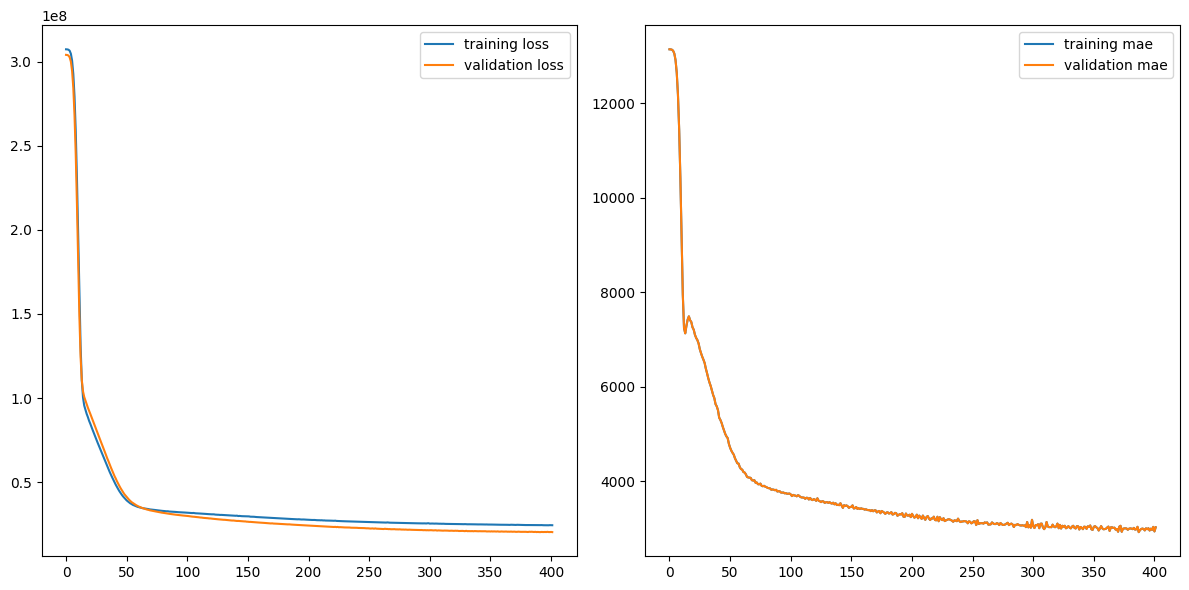

In [ ]:
# summarize history of loss and accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.lineplot(history.history["loss"], ax=ax[0], label="training loss")
sns.lineplot(history.history["val_loss"], ax=ax[0], label="validation loss")

sns.lineplot(history.history["mae"], ax=ax[1], label="training mae")
sns.lineplot(history.history["mae"], ax=ax[1], label="validation mae")

plt.tight_layout()
plt.show()

In [22]:
results = pd.DataFrame()
y_pred = model.predict(X_test)

results["test"] = y_test
results["pred"] = y_pred
results

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,test,pred
900,8688.85885,9634.750977
1064,5708.86700,8100.364746
1256,11436.73815,14084.155273
298,38746.35510,34122.503906
237,4463.20510,5314.092773
...,...,...
534,13831.11520,16056.651367
542,13887.20400,16256.172852
760,3925.75820,6856.488281
1284,47403.88000,46150.472656


In [ ]:
# model evaluation using different metrics
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MSE: 21944689.231443286
RMSE: 4684.515901503942
MAE: 2982.943588044893
R2 Score: 0.8805770609750594


In [19]:
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

In [ ]:
# model save
model.save("./insurance_ann.keras")

### Model Testing

In [1]:
import pickle
from tensorflow import keras

In [2]:
with open("./preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

In [3]:
model = keras.models.load_model("./insurance_ann.keras")

In [43]:
user_input = pd.DataFrame([{
    "age": 19,
    "bmi": 27.9,
    "children": 0,
    "sex": "male",
    "smoker": "no",
    "region": "southwest"
}])

processed = preprocessor.transform(user_input)

In [45]:
model.predict(processed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


array([[2731.82]], dtype=float32)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
